In [136]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

In [137]:
#Sneak peek of the data
df = pd.read_csv('online_retail.csv')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [138]:
df.shape

(541910, 8)

### Data Cleaning

In [139]:
#Checking for missingness
df.isna().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [140]:
#Dropping missing customerIDs
df = df.dropna(subset=['Customer ID'])

In [141]:
df.describe()

,Quantity,Price,Customer ID
count,406830.000000,406830.000000,406830.000000
mean,12.061276,3.460507,15287.684160
std,248.693065,69.315080,1713.603074
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13953.000000
50%,5.000000,1.950000,15152.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [142]:
#Checking for negative quantity rows
df[df['Quantity'] < 0].value_counts()

Invoice  StockCode  Description                          Quantity  InvoiceDate       Price  Customer ID  Country       
C543611  82483      WOOD 2 DRAWER CABINET WHITE FINISH   -1        2/10/2011 14:38   4.95   17850.0      United Kingdom    4
C538341  22976      CIRCUS PARADE CHILDRENS EGG CUP      -12       12/10/2010 14:03  1.25   15514.0      United Kingdom    3
         22730      ALARM CLOCK BAKELIKE IVORY           -1        12/10/2010 14:03  3.75   15514.0      United Kingdom    3
         22725      ALARM CLOCK BAKELIKE CHOCOLATE       -1        12/10/2010 14:03  3.75   15514.0      United Kingdom    3
C550165  22962      JAM JAR WITH PINK LID                -1        4/14/2011 16:34   0.85   15358.0      United Kingdom    2
                                                                                                                          ..
C581464  23458      DOLLY CABINET 3 DRAWERS              -1        12/8/2011 18:57   14.95  15951.0      United Kingdom    1
     

In [143]:
#Dropping negative quantity rows
df = df[df['Quantity'] > 0]

In [144]:
df.shape

(397925, 8)

### Feature Engineering

In [145]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [146]:
df['Revenue'] = df['Quantity']*df['Price']

In [147]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [148]:
df.dtypes

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
Revenue        float64
dtype: object

In [149]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [150]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
recency = (reference_date - df.groupby('Customer ID')['InvoiceDate'].max()).dt.days

In [151]:
frequency = (df.groupby('Customer ID')['Invoice'].nunique())

In [152]:
customer_revenue = (df.groupby('Customer ID')['Revenue'].sum())

In [153]:
avg_order_value = (total_revenue / frequency)

In [154]:
unique_products = (df.groupby('Customer ID')['StockCode'].nunique())

In [155]:
total_qty = (df.groupby('Customer ID')['Quantity'].sum())

In [156]:
customer_df = pd.DataFrame(index=df['Customer ID'].unique())

In [157]:
#Concatenating all new feature series into the customer dataframe
customer_df['Recency'] = recency
customer_df['Frequency'] = frequency
customer_df['customer_revenue'] = customer_revenue
customer_df['AvgOrderValue'] = customer_revenue / frequency
customer_df['UniqueProducts'] = unique_products
customer_df['TotalQuantity'] = total_qty

In [158]:
customer_df.head()

,Recency,Frequency,customer_revenue,AvgOrderValue,UniqueProducts,TotalQuantity
17850.0,372,34,5391.21,158.565000,21,1733
13047.0,32,10,3237.54,323.754000,106,1391
12583.0,3,15,7281.38,485.425333,115,5060
13748.0,96,5,948.25,189.650000,24,439
15100.0,334,3,876.00,292.000000,1,80


In [159]:
customer_df.shape

(4339, 6)

### EDA

In [160]:
customer_df.describe()

,Recency,Frequency,customer_revenue,AvgOrderValue,UniqueProducts,TotalQuantity
count,4339.000000,4339.000000,4339.000000,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2053.797166,419.048739,61.489283,1194.214566
std,100.009747,7.705493,8988.247836,1796.320698,85.363900,5055.603014
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,18.000000,1.000000,307.245000,178.505000,16.000000,160.000000
50%,51.000000,2.000000,674.450000,293.690000,35.000000,379.000000
75%,142.000000,5.000000,1661.640000,430.022500,77.000000,993.000000
max,374.000000,210.000000,280206.020000,84236.250000,1787.000000,197491.000000


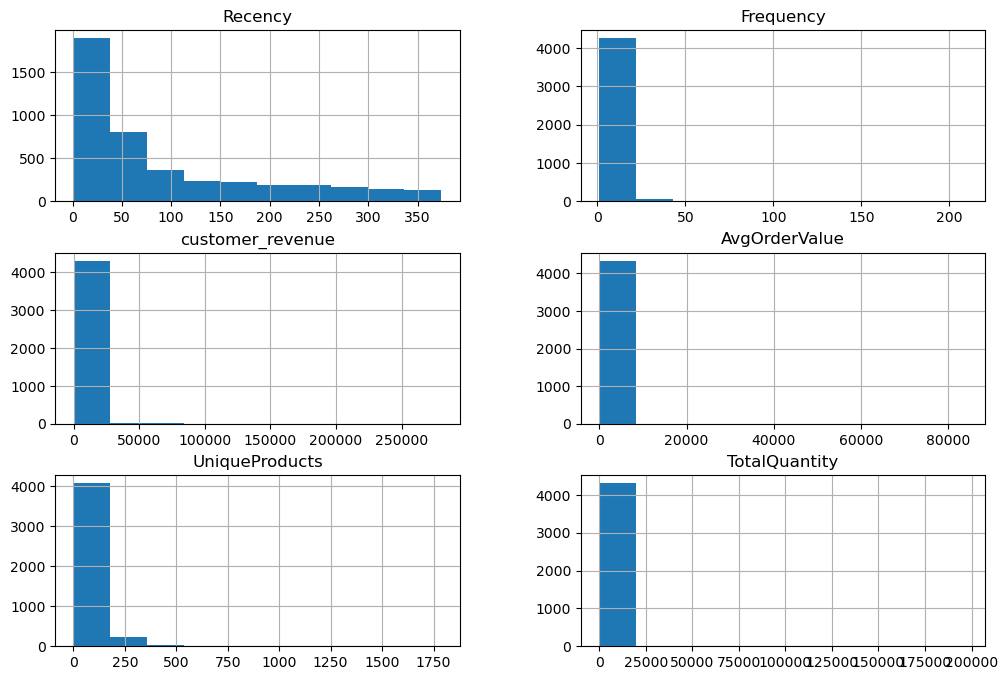

In [161]:
#Distribution of customer activity
customer_df.hist(figsize=(12,8))
plt.savefig('Customer activity distribution.png')

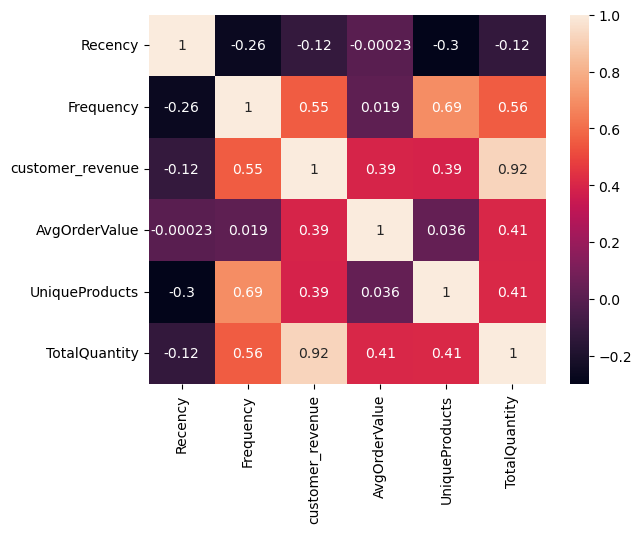

In [162]:
# Correlation of Customer activity
sns.heatmap(customer_df.corr(), annot=True)
plt.savefig('Correlation of Customer activity.png')
plt.show()

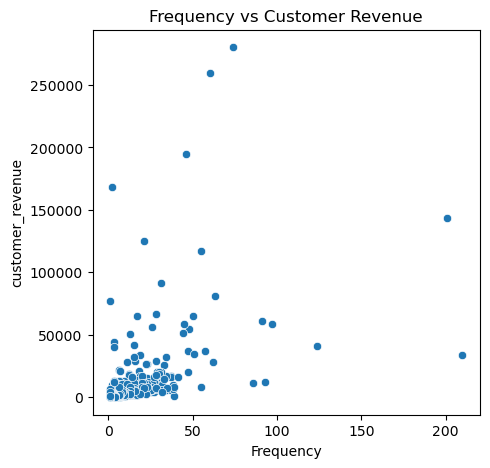

In [163]:
#Distribution of frequency and customer revenue
plt.figure(figsize=(5,5))
sns.scatterplot(data=customer_df,x='Frequency',y='customer_revenue')

plt.title('Frequency vs Customer Revenue')
plt.savefig('frequency_vs_crevenue.png', dpi=300)
plt.show()

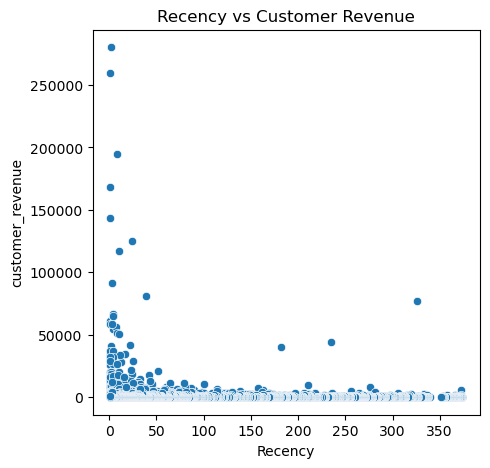

In [164]:
# Distribution of frequency and customer revenue
plt.figure(figsize=(5,5))
sns.scatterplot(data=customer_df,x='Recency',y='customer_revenue')

plt.title('Recency vs Customer Revenue')
plt.savefig('recency_vs_crevenue.png', dpi=300)
plt.show()

### Feature Scaling

In [165]:
#Scaling features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df)

### PCA

In [86]:
#Fitting a base pca and checking how variance is explained by various components
from sklearn.decomposition import PCA
pca = PCA()
pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

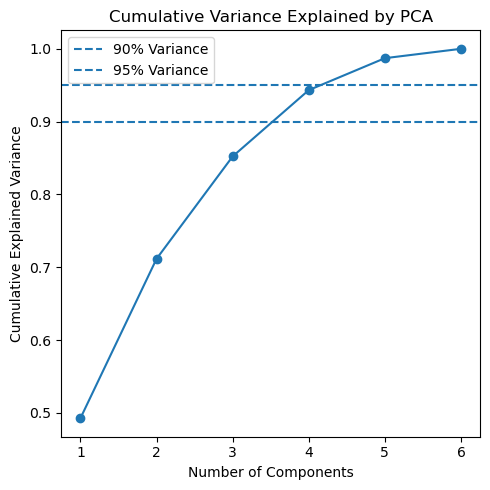

In [173]:
#Visualizing how variance trends with nuber of components
plt.figure(figsize=(5,5))

plt.plot(range(1, len(cumulative_variance)+1),cumulative_variance,marker='o')

plt.axhline(y=0.90, linestyle='--', label='90% Variance')
plt.axhline(y=0.95, linestyle='--', label='95% Variance')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained by PCA")

plt.legend()
plt.tight_layout()
plt.savefig("pca_cumulative_variance.png", dpi=300)
plt.show()

### K-Means

In [174]:
#Fitting and trasnforming on the scaled data
pca = PCA(n_components=4)
X_pca_4 = pca.fit_transform(X_scaled)

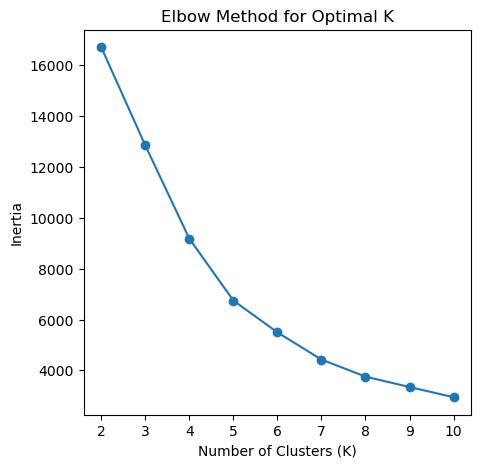

In [175]:
#Checking for inertia of the pca4 at different values of k using the elbow method
from sklearn.cluster import KMeans
inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca_4)
    inertia.append(km.inertia_)

plt.figure(figsize=(5,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

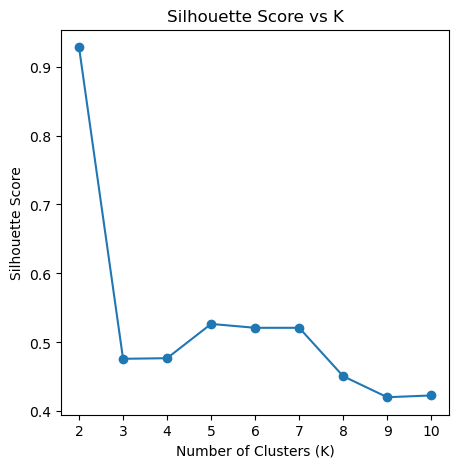

In [176]:
#Checking the silhouette score for the pca4 at different values of k
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca_4)
    score = silhouette_score(X_pca_4, labels)
    sil_scores.append(score)

plt.figure(figsize=(5,5))
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

In [177]:
#Fitting our prefered number of clusters on the 4 component data)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca_4)

In [178]:
customer_df['Cluster'] = clusters
customer_df.head()

,Recency,Frequency,customer_revenue,AvgOrderValue,UniqueProducts,TotalQuantity,Cluster
17850.0,372,34,5391.21,158.565000,21,1733,1
13047.0,32,10,3237.54,323.754000,106,1391,4
12583.0,3,15,7281.38,485.425333,115,5060,0
13748.0,96,5,948.25,189.650000,24,439,4
15100.0,334,3,876.00,292.000000,1,80,1


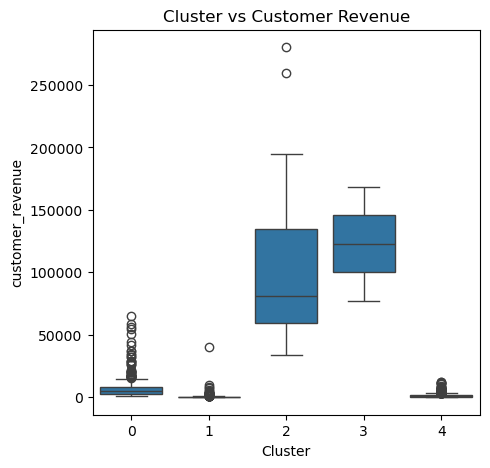

In [179]:
#Visualizing distribution of clusters and their revenue
plt.figure(figsize=(5,5))
sns.boxplot(data=customer_df,x='Cluster',y='customer_revenue')

plt.title("Cluster vs Customer Revenue")
plt.savefig("cluster_vs_customer_revenue.png", dpi=300)
plt.show()

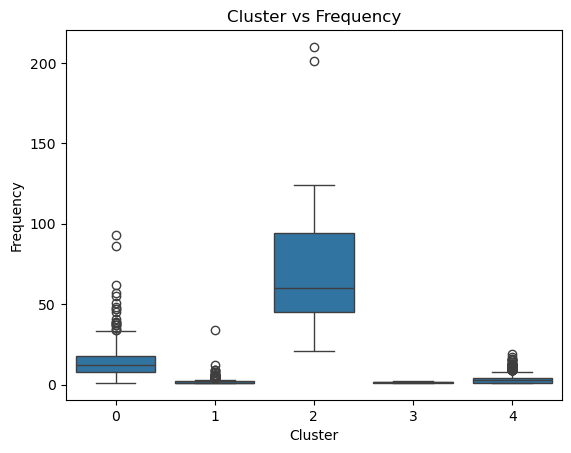

In [180]:
#Visualizing frequency of clusters
sns.boxplot(data=customer_df,x='Cluster',y='Frequency')

plt.title("Cluster vs Frequency")
plt.savefig("cluster_vs frequency.png", dpi=300)
plt.show()

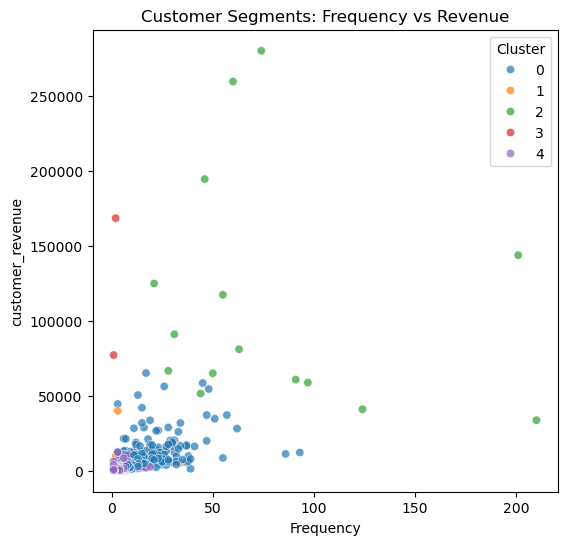

In [106]:
#Distributi
plt.figure(figsize=(5,5))

sns.scatterplot(data=customer_df,x='Frequency',y='customer_revenue',hue='Cluster',palette='tab10',alpha=0.7)

plt.title("Customer Segments: Frequency vs Revenue")
plt.savefig("clusters_frequency_monetary_scatter.png", dpi=300)
plt.show()

In [104]:
cluster_map = {
    0: "Regular Low-Value Customers",
    1: "Inactive  Customers",
    2: "High-Value Customers",
    3: "Rare High-Spenders",
    4: "Low-Value Occasional Customers"
}

customer_df['Segment'] = customer_df['Cluster'].map(cluster_map)

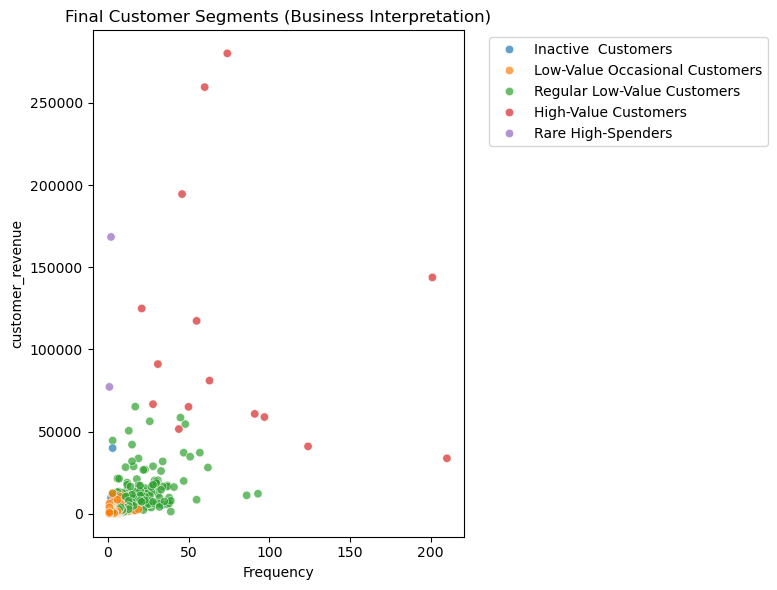

In [105]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer_df,
    x='Frequency',
    y='customer_revenue',
    hue='Segment',
    palette='tab10',
    alpha=0.7
)

plt.title("Final Customer Segments (Business Interpretation)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("final_segments.png", dpi=300)
plt.show()